# Bayesian inference: Modeling

## Table of Content:

- IV [Simple Bayesian Modeling](#IV.-Simple-Bayesian-Modeling)
    * IV.1 [The model](#IV.1-The-model)
    * IV.2 [The prior](#IV.-2-The-prior): Conjugate, empirical, flat and non informative priors
    * IV.3 [Implementation](#IV.3-Implementation)
- V Bayesian modeling with Monte Carlo Markov Chains (MCMC): See [Bayes_MCMC.ipynb](Bayes_MCMC.ipynb)
- X [References](#XX-References:)

## IV. Simple Bayesian Modeling

We'll start with the classic model fitting problem: **Fitting a line to data**.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats
import scipy.optimize

For the sake of illustration, we will generate a fake data set. 

<ErrorbarContainer object of 3 artists>

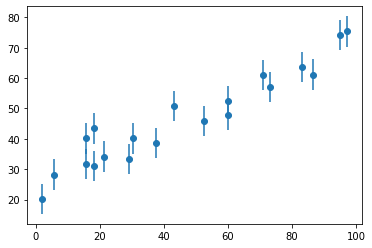

In [2]:
# Function that generates points following a linear trend. 
def make_data(intercept, slope, N=20,sigy=5, rseed=42):
    '''
    Parameters:
    -----------
    intercept, slope: parameters of the linear model
    sigy: width of normally distributed data points around the "true line"
    rseed: Seed of the random number generator (fixed for the sake of discussion)
    Output:
    -------
    x, y, sig_y 
    '''
    rand = np.random.RandomState(rseed)
    x = 100 * rand.rand(N)
    y = intercept + slope * x
    y += sigy * rand.randn(N)
    return x, y, sigy * np.ones_like(x)

theta_true = [25, 0.5]
x, y, sigy = make_data(theta_true[0], theta_true[1])  # could also be make_data(*theta_true)
plt.errorbar(x, y, sigy, fmt='o')

### IV.1 The model

Next we need to specify a model. We're fitting a straight line to data, so we'll need a slope and an intercept; i.e.

$$
y_M(x) = \theta_0 + \theta_1\,x 
$$

where our parameter vector might be 

$$
\boldsymbol{\theta} = [\theta_0, \theta_1]
$$

But this is only half the picture: what we mean by a "model" in a Bayesian sense is not only the expected value $<y(x;\boldsymbol{\theta})>$, but a **probability distribution** for our data.
That is, we need an expression to compute the likelihood $P(D\mid\theta)$ for our data as a function of the parameters $\boldsymbol{\theta}$.

You may remember from the [previous lecture](../05-MLE_and_regression/Regression_short.ipynb) that the likelihood for n (independent) points ($y_i$) drawn from a normal distribution:
$$
y_i \sim N(y_M(x_i; \boldsymbol{\theta}), \sigma)
$$
the likelihood is the product of the probabilities for each single data point, namely:

$$
p(y_i\,\mid\,\boldsymbol{\theta} ) = \frac{1}{\sigma \sqrt{2\,\pi}} \, \exp\left[-0.5 \left (\frac{y_i - y_M(x_i; \boldsymbol{\theta})}{\sigma} \right)^2\right] 
$$

Hence (generalised to heteroscedastic errors):

$$
L \equiv P(D\mid\boldsymbol{\theta}) = \prod_{i=1}^N P(x_i,y_i\mid\boldsymbol{\theta})
$$

$$
P(D\mid\boldsymbol{\theta}) =  \prod_{i=1}^{N} \frac{1}{\sqrt{2\,\pi \sigma_i^2}} \, \exp\left[\left (\frac{ -(y_i - (\theta_0+\theta_1\,x_i))^2}{2\,\sigma_i^2} \right)\right]
$$

Or, written in terms of log-likelihood:

$$
\ln(P(D\mid\boldsymbol{\theta})) \, = -\frac{1}{2}\,\sum_{i=1}^{N} \left (\ln(2\pi\sigma_i^2) + \frac{ (y_i - (\theta_0+\theta_1\,x_i))^2}{\sigma_i^2} \right) 
$$

We can now write a function that computes the log-likelihood given a parameter vector $\boldsymbol{\theta}$, an array of errors $\sigma_i$, and an array of $x$ and $y$ values.


In [3]:
def ln_likelihood(theta, x, y, sigy):
    y_model = theta[0] + theta[1] * x
    return -0.5 * np.sum(np.log(2 * np.pi * sigy ** 2) + (y - y_model) ** 2 / sigy ** 2)

The frequentist approach would be to search for the maximum of the likelihood. The Bayesian approach is more comprehensive. It is not a matter of finding the most likely estimator of $\theta$ but of deriving the **full posterior probability** $P(\boldsymbol{\theta}~\mid~D)$. For that purpose we need to set a prior ... 

In [4]:
# Fequentist way - Least square regression
# We can also search the best fit with np.polyfit as the best parameters are, by construction, those that maximise the likelihood
res_polyfit = np.polyfit(x, y, 1, w=1/sigy)
print('MLE parameters with polyfit (intercept, slope) = (%.3f, %.3f)' %(res_polyfit[1], res_polyfit[0]))

MLE parameters with polyfit (intercept, slope) = (24.818, 0.474)


In [5]:
# Let's search for the maximum likelihood values of the parameters 
# For this let's take -ln(P) and use the function scipy.optimize.minimize() which searches for the minimum of a function
def ln_likelihood2(theta, x, y, sigy):
    """
    -ln(P) : function to be fed to scipy.optimize.fmin()
    """
    y_model = theta[0] + theta[1] * x
    return 0.5 * np.sum(np.log(2 * np.pi * sigy ** 2) + (y - y_model) ** 2 / sigy ** 2)

# Let's calculate the maximum likelihood using scipy.optimize.minimize()
# This is a generic method that implements minimization. Several "optimization" method exist
result_MLE = scipy.optimize.minimize(ln_likelihood2, x0=theta_true, args=(x,y,sigy), method='Nelder-Mead')   
print('Maximum likelihood value of model params (intercept, slope) = (%.3f, %.3f)' %(result_MLE.x[0], result_MLE.x[1]))

Maximum likelihood value of model params (intercept, slope) = (24.818, 0.474)


We see that the two methods yield the same point-estimate of the parameters. These values are maximizing the likelihood. In the bayesian framework, we are not only interested in knowing those values, but getting the full posterior associated to the parameters. 

**Note**: The `scipy.optimize.minimize()` implemented above is not doing gradient descent (i.e. it does not calculate / use 1st and 2nd derivatives of the function). It is using the [Nelder-Mead algorithm](http://www.scholarpedia.org/article/Nelder-Mead_algorithm) better known as *simplex* or *amoeba*. It evaluates the function on a polytope of n+1 vertices in n dimension (a polytope a geometric object of dimension n+1 with flat sides or in other words it is the generalisation of a polyedra in $n$ dimensions; e.g. a triangle in 2D space is a polytope). At each iteration, the value of the function at each point is evaluated, and a new test point is estimated based on the points in hands. 

### IV. 2 The prior

#### IV.2.1 Conjugate priors

In the early days of Bayesian analysis, people were considering [conjugate prior](https://en.wikipedia.org/wiki/Conjugate_prior). A *conjugate prior* is a prior which, due to its mathematical relation to the likelihood, makes the result analytically computable. Those priors are rarely defensible on any grounds other than computational convenience, and so this is **almost never a good choice**.

#### IV.2.2 Empirical priors

Empirical Priors are priors which are actually posteriors from previous studies of the same phenomenon. For example, it's common in Supernova cosmology studies to use the WMAP results as a prior: that is, we actually plug-in a *real result* and use our new data to improve on that. This situation is where Bayesian approaches really shine.

For our linear fit, you might imagine that our $x, y$ data is a more accurate version of a previous experiment, where we've found that the intercept is $\theta_0 = 50 \pm 30$ and the slope is $\theta_1 = 1.0 \pm 0.5$.
In this case, we would encode this prior knowledge in the prior distribution itself.

#### IV.2.3 Flat Priors

If you don't have an empirical prior, you might be tempted to simply use a *flat prior* – i.e. a prior that is constant between two reasonable limits (i.e. equal probability slopes from -1000 to +1000). You may also call it **uniform** (it is uniform between 2 bounds and 0 outside). 

The problem is that flat priors are not always non-informative! For example, a flat prior on the slope will effectively give a higher weight to larger slopes.
We can see this straightforwardly by plotting regularly-spaced slopes between 0 and 20:

(-1, 1)

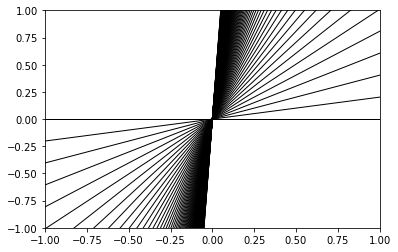

In [6]:
xx = np.linspace(-1, 1)
for slope in np.linspace(0, 20, 100):
    plt.plot(xx, slope * xx, '-k', linewidth=1)
plt.xlim(-1, 1)
plt.ylim(-1,1)
#plt.axis([-1, 1, -1, 1], aspect='equal')

Text(0.5, 0, 'Slope')

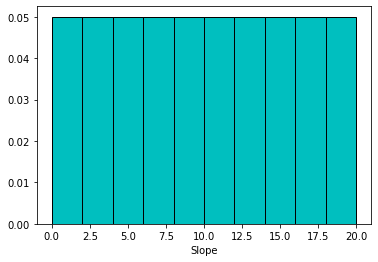

In [7]:
# You can see that the above prior on the slope is uniform (= flat) between 0 and 20 
slopes = np.linspace(0, 20, 100)
qq = plt.hist(slopes, density=True, color='c', edgecolor='k')
plt.xlabel('Slope')  

The density of the lines is a proxy for the probability of those slopes with a flat prior.
This is an important point to realize: **flat priors are not necessarily minimally informative**.

#### IV.2.4 Non-informative Priors

What we *really* want in cases where no empirical prior is available is a **non-informative prior**. Among other things, such a prior should not depend on the units of the data.
Perhaps the most principled approach to choosing non-informative priors was the *principle of maximum entropy* advocated by Jaynes ([book](https://omega0.xyz/omega8008/JaynesBookPdf.html)).

Similar in spirit is the commonly-used [Jeffreys Prior](https://en.wikipedia.org/wiki/Jeffreys_prior), which in many cases of interest amounts to a "scale invariant" prior: a flat prior on the logarithm of the parameter.

In the case of the linear slope, we often want a prior which does not artificially over-weight large slopes: there are a couple possible approaches to this (see http://arxiv.org/abs/1411.5018 for some discussion). For our situation, we might use a flat prior on the angle the line makes with the x-axis, which gives

$$
P(\theta_1) \propto (1 + \theta_1^2)^{-3/2}
$$

For lack of a better term, we can call this a "symmetric prior" on the slope. Indeed, it is the same whether we are fitting $y = \theta_1 \, x + \theta_0$ or $x = \theta_1^\prime\,y + \theta_0^\prime$.

In [8]:
theta_1 = np.linspace(-10, 10, 1000000)
# The cdf of this function would be 0.5 * theta1 / sqrt(1+theta1^2) + 0.5
cdf_num = 0.5 * theta_1 / np.sqrt(1+theta_1**2) + 0.5 

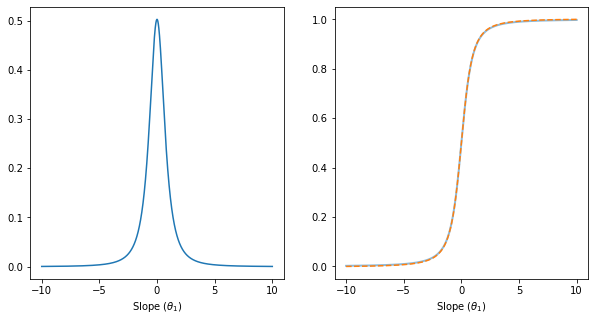

In [9]:
# For the sake of illustration we can also try to manage this purely numerically
# let's try to generate samples from that prior numerically

P_theta1 = (1 + theta_1**2)**(-1.5)
pdf_theta1 = P_theta1 / np.trapz(P_theta1, theta_1) 

# If we were too lazy to calculate the cdf 
dtheta = np.mean(np.diff(theta_1))
cdf_theta1  = np.cumsum(pdf_theta1 * dtheta)
f, ax = plt.subplots(ncols=2, figsize=(10,5))
ax[0].plot(theta_1, pdf_theta1)
[ax[i].set_xlabel(r"Slope ($\theta_1)$") for i in range(2)]
ax[1].plot(theta_1, cdf_num, ls='-', lw=2, alpha=0.5)
ax[1].plot(theta_1, cdf_theta1, ls='--')

In [10]:
# To generate random sample I should draw uniform values between 0 and 1 
# and read the cdf "from y" to derive samples of theta_1.
rnd_pts = scipy.stats.uniform.rvs(0, 1, size=1000000)
# One can find that the inverse of the cdf is x = (y-0.5) / sqrt(y *(1-y))
rnd_slopes_num = (rnd_pts - 0.5) / np.sqrt(rnd_pts * (1-rnd_pts))
# a numerical approach - without calculating the integral analytically
rnd_slopes = theta_1[np.searchsorted(cdf_theta1, rnd_pts)] # values of the slope drawn from the distrib. of interest
# Note that the use of searchsorted might not be super accurate! 

(-10, 10)

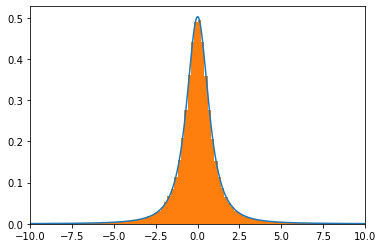

In [11]:
# let's verify that the drawn sample follow the defined pdf
plt.plot(theta_1, pdf_theta1)
#plt.hist(rnd_slopes, bins=100, density=True); # numerical approach
plt.hist(rnd_slopes_num, bins=100, density=True, range=(-10,10));
plt.xlim(-10,10)

[(-1, 1), (-1, 1)]

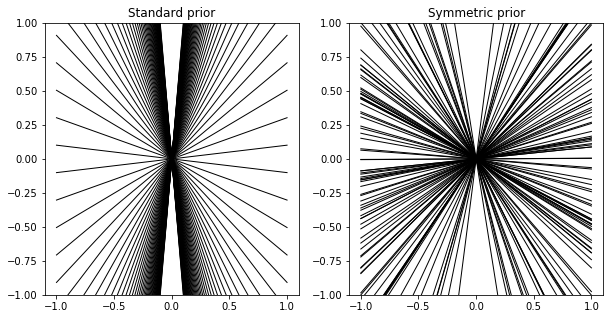

In [12]:
# At least for the sake of illustration the above procedure enables to generate random slopes from the chosen distribution 
# Let's select 100 of those slopes and visualise them 

f, ax = plt.subplots(ncols=2, figsize=(10,5))
xx = np.linspace(-1, 1, 10)
uni_slope = np.linspace(-10, 10, 100)
sym_slope = np.random.choice(rnd_slopes_num, size=100, replace=False)
for i in range(100):
    ax[0].plot(xx, uni_slope[i] * xx, '-k', linewidth=1)
    ax[1].plot(xx, sym_slope[i] * xx,  '-k', linewidth=1)  # I only take positive slopes for comparison
ax[0].set_title("Standard prior")
ax[1].set_title("Symmetric prior")
[ax[j].set_ylim(-1,1) for j in range(2)]

In [ ]:
angle_symm = np.arctan(rnd_slopes_num)
plt.hist(angle_symm, alpha=0.5, density=True, label='Symmetric prior', bins=60);
# Symmetric prior, slopes calculated numerically
#angle_symm_m2 = np.arctan(rnd_slopes)
#plt.hist(angle_symm_m2, alpha=0.3, density=True, label='Symmetric prior', bins=60);
# Uniform slope prior
plt.hist(np.arctan(np.linspace(-10, 10, 1000)), alpha=0.5, density=True, bins=60, label='Uniform prior');
plt.xlabel('Angle of straight line (radians)')
plt.legend()

The symmetric prior does not yield a perfectly uniform prior on the angle as stated in http://arxiv.org/abs/1411.5018 but it is much less asymmetric than the uniform prior on the slope. 

## IV.3 Implementation

Let's define two python functions to compute the options for our prior: we'll use both a (log) flat prior and a (log) symmetric prior.
In general, we need not worry about the normalization of the prior or the likelihood, which makes our lives easier:

In [14]:
def ln_flat_prior(theta):
    '''
    theta = shape(2) array containing the [intercept, slope] = [theta_0, theta_1]
    '''
    if np.abs(theta[1]) < 1000:
        return 0 # log(1)
    else:
        return -np.inf  # log(0)
    
def ln_symmetric_prior(theta):
    '''
    theta = shape(2) array containing the [intercept, slope] = [theta_0, theta_1]
    '''
    if np.abs(theta[1]) < 1000:
        return -1.5 * np.log(1 + theta[1] ** 2)
    else:
        return -np.inf  # log(0)

With these defined, we now have what we need to compute the log posterior as a function of the model parameters.
You might be tempted to maximize this posterior in the same way that we do with the likelihood when performing a $\chi^2$ regression. However, the proper Bayesian approach is not just a matter of getting the maximum of the posterior of our parameters but aims at getting the (possibly marginalized) posterior probability for our parameters. 

Remember that the posterior probability on the parameters is the product of the likelihood and of the prior. Hence the log of the posterior is the sum of the log of these two quantities. For the simple case above, we can explicitly evaluate the log probability on a grid for the 2 parameters of our model. 

#### Exercise:

1. Calculate the posterior probability distribution on a grid of 100x100 values of slope and intercept (e.g. between 15-35 for the intercept and 0.3 and 0.7 for the slope) for each of the 2 priors. Using matplotlib, plot the posterior probability distribution for the slope and intercept. To make a contour plot with matplotlib, you can use ``plt.contourf()`` or ``plt.pcolor()``. How different are the distributions for the 2 priors ?

2. Modify the dataset – how do the results change if you have very few data points or very large errors?

3. Plot the 1-sigma, 2-sigma, and 3-sigma contours to your plot using the function contour_levels() given below. 

In [ ]:
# Use the cells below to evaluate the log likelihood for each of the two priors above
# Function that returns an array ln(posterior) for a flat/symmetric prior on a grid of values for the slope and intercept
def ln_P():
    '''
    Function to calculate ln(posterior) for a flat prior  
 
    Returns: ln(posterior)
    '''

    return lnP_arr

In [ ]:
# Evaluate ln(P) for a flat prior for our data set 

# Evaluate ln(P) for symmetric prior


In [ ]:
# Create the grid of SLOPES/INTERCEPTS values for which you have evaluated ln(posterior) 
# TIP: Use np.meshgrid


In [ ]:
# Plot the results


In [ ]:
# Function to compute 1, 2, 3-sigma contour levels for a gridded 2D posterior 
# Gaussian assumption for the levels 
def contour_levels(grid):
    """
    Compute 1, 2, 3-sigma contour levels for a gridded 2D posterior
    In 2D - assuming a Gaussian bivariate distribution, 
    the [68, 95, 99.7] levels correspond to [39.3, 86.5, 98.9] contours
    (see V.2.2.4 in Bayes_MCMC.ipynb)
    
    Parameter: 
    ----------
    grid: np.array((n,n)) - 2D grid with the posterior   
    """
    sorted_P = np.sort(grid.ravel())[::-1]   # P ordered from largest to lowest
    pct = np.cumsum(sorted_P) / np.sum(sorted_P)   # Integrated volume from the peak of the 2D PDF array (normalized by the total volume)
    cutoffs = np.searchsorted(pct, np.array([0.989, 0.865, 0.393]))  # cutoffs need to be increasing, i.e. out to in due to function contour 
    return sorted_P[cutoffs]

In the present case, you'll see that the form of the prior makes little difference on the results. This is often, but not always the case if you have enough data to constrain your model. Instead, if you have few data and/or large error bars, your results is more likely to be prior dependent which means that, if you do not have good data, you won't improve much your knowledge about the world you are probing with your data !  

In [ ]:
# Generate a data set with only 3 data points to see impact of e.g. a flat prior 

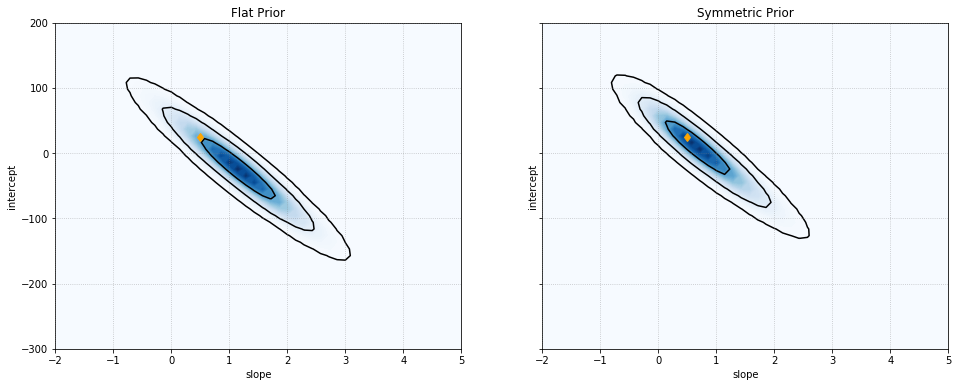

We see that the results are more prior dependant. 

## V. Bayesian Modeling with MCMC

See [Bayes_MCMC.ipynb](Bayes_MCMC.ipynb)

## XX References:

**Chapter 5** (5.1, 5.2, 5.3, 5.8) of the book <a class="anchor" id="book"></a> *Statistics, data mining and Machine learning in astronomy* by Z. Ivezic et al. in Princeton Series in Modern Astronomy. 

- This notebook includes a large fraction of the material that J. Vander Plas gave during the "Bayesian Methods in Astronomy workshop", presented at the 227th meeting of the American Astronomical Society. The full repository with that material can be found on GitHub: http://github.com/jakevdp/AAS227Workshop

- More insights on the differences between frequentist and Bayesian approaches: see [J. VanderPlass blog posts](http://jakevdp.github.io/blog/2014/03/11/frequentism-and-bayesianism-a-practical-intro/) 

- Jayes: [*Probability Theory: The Logic of Science*](http://bayes.wustl.edu/etj/prob/book.pdf).

- A short paper discussing priors: Jaynes, 1968, IEEE Trans. on Systems Science and Cybernetics, SSC-4, 227: [*Prior Probabilities*](https://bayes.wustl.edu/etj/articles/prior.pdf)

- For some approachable reading on frequentist vs. Bayesian uncertainties, I'd suggest [The Fallacy of Placing Confidence in Confidence Intervals](https://learnbayes.org/papers/confidenceIntervalsFallacy/), as well as Jake VanderPlast blog post on the topic, [Confidence, Credibility, and why Frequentism and Science do not Mix](http://jakevdp.github.io/blog/2014/06/12/frequentism-and-bayesianism-3-confidence-credibility/).

- Foreman-Mackey et al. 2012 [*EMCEE, the MCMC hammer*](https://arxiv.org/abs/1202.3665) ; see also http://dan.iel.fm/emcee/current/

- About the variety of approaches to MCMC: Allison and Dunkley 2013: [Comparison of sampling techniques for Bayesian parameter estimation](https://arxiv.org/abs/1308.2675). See also [How to Be a Bayesian in Python](http://jakevdp.github.io/blog/2014/06/14/frequentism-and-bayesianism-4-bayesian-in-python/). 

- Andreon 2011 [Understanding better (some) astronomical data using Bayesian methods](https://arxiv.org/abs/1112.3652)